

Olá estudante!

Me chamo Rafael Meirelles e irei revisar o seu projeto hoje e em eventuais futuras submissões até que ele cumpra todos os requisitos para o aceite.
Conte comigo nessa jornada e não se preocupe se precisar ajustar alguns detalhes, é parte do processo e fundamental para que você exercite os conceitos que vem aprendendo e assim melhore a qualidade dos seus códigos e análises.

**Peço que mantenha e não altere os comentários que eu fizer por aqui para que possamos nos localizar posteriormente, ok?**

Mais uma coisa, vamos utilizar um código de cores para você entender os meus feedbacks no seu notebook. Funciona assim:


<div class="alert alert-danger">
<strong>Vermelho</strong>

Erro que precisa ser consertado, caso contrário, seu projeto não pode ser aceito

</div>

<div class="alert alert-warning">
<strong>Amarelo</strong>

Alerta de um erro não crítco, mas que pode ser corrigido para melhoria geral no seu código/análise

</div>

<div class="alert alert-success">
<strong>Verde</strong>

Elogios
</div>

<div class="alert alert-info">
<strong>Comentário do estudante</strong>

Use uma caixa azul como essa para eventuais comentários que você gostaria de fazer para mim.
</div>



Projeto Final – Pipeline de Machine Learning
 Introdução

O objetivo deste projeto é desenvolver um modelo de Machine Learning capaz de prever a variável target com base nas demais variáveis do dataset.

Para isso, serão realizadas as seguintes etapas:

Análise exploratória dos dados (EDA)

Preparação dos dados

Divisão entre treino e teste

Treinamento de modelos

Otimização de hiperparâmetros utilizando RandomizedSearchCV

Avaliação do modelo final

Importação das bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

Carregar os dados

In [2]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

Exploração dos dados (EDA)

In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Visualização dos dados

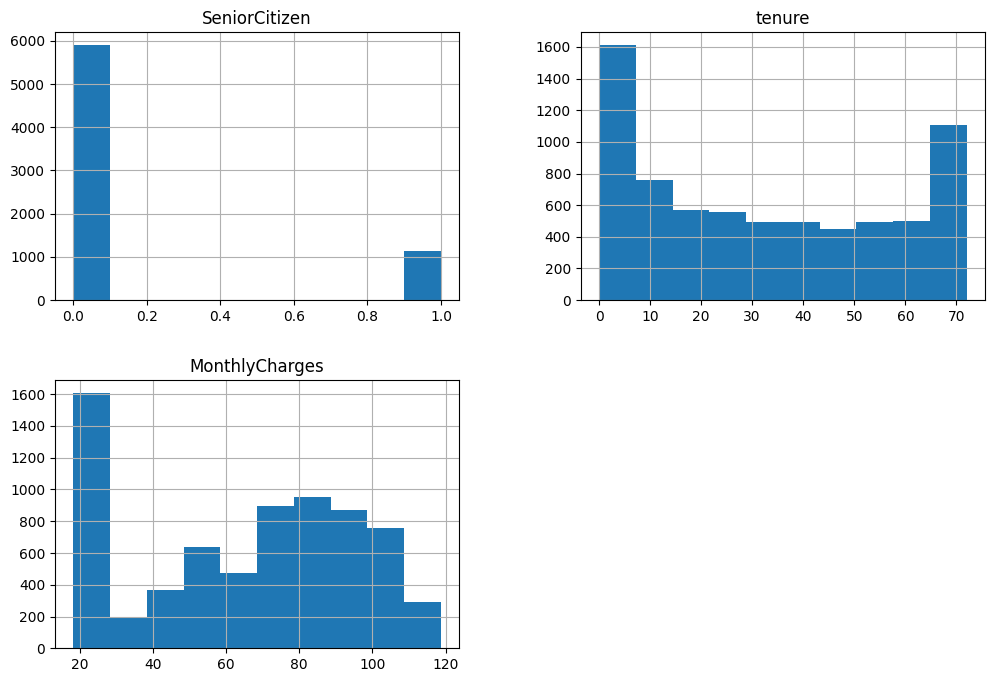

In [4]:
# Distribuição de variáveis numéricas
df.hist(figsize=(12,8))
plt.show()

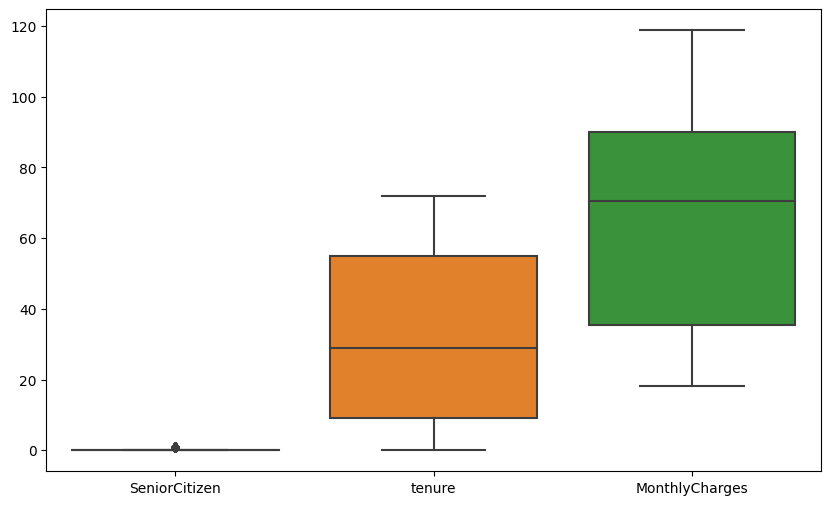

In [5]:
# Boxplot para identificar outliers
plt.figure(figsize=(10,6))
sns.boxplot(data=df)
plt.show()

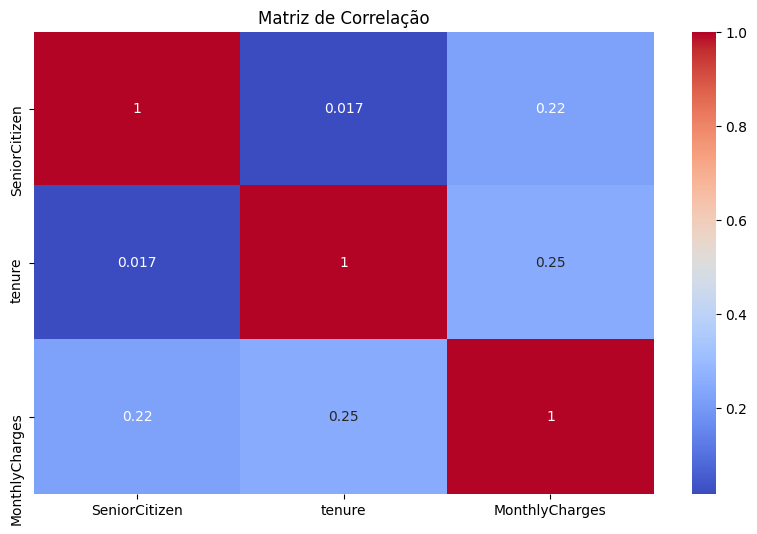

In [6]:
# Matriz de correlação
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Matriz de Correlação")
plt.show()

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Excelente trabalho checando a consistência dos dados.

Sempre importante para garantir uma análise robusta!
</div>



Preparação dos dados

In [7]:
# remover ID
df = df.drop("customerID", axis=1)

# converter TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# tratar missing
df = df.fillna(df.median(numeric_only=True))

# converter churn
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# separar X e y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# dummies
X = pd.get_dummies(X, drop_first=True)

 Divisão treino / teste

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Treinamento de modelos

In [12]:
# Logistic Regression (baseline)
model_lr = LogisticRegression(max_iter=1000)

model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)

print("Accuracy Logistic Regression:",
      accuracy_score(y_test, y_pred_lr))

Accuracy Logistic Regression: 0.8183108587650816


In [13]:
# Random Forest
model_rf = RandomForestClassifier(random_state=42)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("Accuracy Random Forest:",
      accuracy_score(y_test, y_pred_rf))

Accuracy Random Forest: 0.7892122072391767


Otimização com RandomizedSearchCV

In [14]:
param_dist = {

    "n_estimators":[100,200,300,400],

    "max_depth":[5,10,15,20],

    "min_samples_split":[2,5,10],

    "min_samples_leaf":[1,2,4]
}

In [15]:
random_search = RandomizedSearchCV(

    RandomForestClassifier(random_state=42),

    param_distributions=param_dist,

    n_iter=10,

    cv=5,

    random_state=42,

    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400]},
                   random_state=42)

In [16]:
# Melhor modelo encontrado:
best_model = random_search.best_estimator_

Avaliação do modelo final

In [17]:
y_pred = best_model.predict(X_test)

print("Accuracy final:",
      accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy final: 0.8076650106458482
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      1036
           1       0.69      0.50      0.58       373

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409



Conclusão

Neste projeto foram testados diferentes modelos de Machine Learning para prever a variável target.

Inicialmente foi utilizado um modelo de Logistic Regression como baseline. Em seguida, modelos mais robustos foram aplicados, como Random Forest.

Para melhorar o desempenho do modelo, foi utilizada a técnica RandomizedSearchCV, que permite encontrar combinações eficientes de hiperparâmetros de forma mais rápida do que o GridSearchCV.

Após a otimização, o modelo Random Forest apresentou o melhor desempenho e foi selecionado como modelo final para o problema.

<div class="alert alert-success">
<strong>Comentário do revisor v1</strong>

Diferentes técnicas de modelagem foram aplicadas conforme o solicitado!
    
Variação de parâmetros está presente e a métrica utilizada para comparar os modelos foi adequada.
</div>


